Akurasi Model Random Forest: 91.22 %


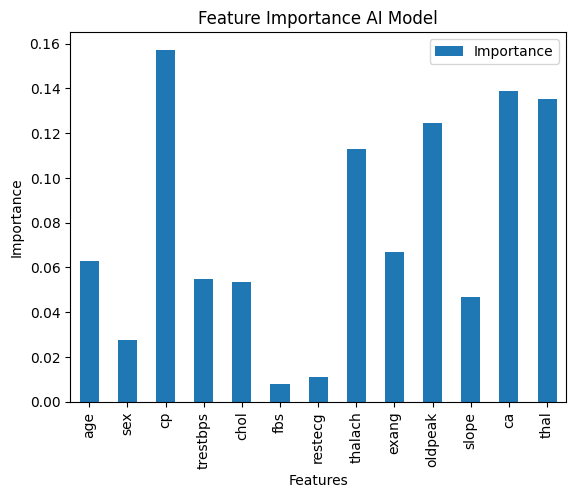

In [23]:

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/heart.csv')
df1 = pd.read_csv('../data/heart10k.csv')

#Data fraame dari data hasil UCI Heart Deases Dataset
new_df = pd.DataFrame(
    df,
    columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
        'restecg', 'thalach', 'exang', 'oldpeak', 
        'slope', 'ca', 'thal', 'target'
        ],    
)

#Rumus mencari faktor nyeri dada: jika nilai CP=0 (Typical Angina) beri bobot 2. Karena sangat beresiko
new_df['cp_faktor'] = np.where(new_df['cp'] == 0, 2, 0)

#Rumus untuk mencari score resiko: R = (Age x 0.05) + (Trestbps x 0.15) + (Chol x 0.1) + (CP_Factor). 
new_df['Score'] = (
    (new_df['age']* 0.05) + 
    (new_df['trestbps']*0.15) + 
    (new_df['chol']*0.1) + 
    new_df['cp_faktor']
    )

#Klasifikasi data berdasarkan faktor resiko
def tentukan_status(Score):
    if Score < 40: return "Rendah"
    elif 40<=Score<50: return "Sedang"
    else: return "Tinggi"
new_df['Status_resiko'] = new_df['Score'].apply(tentukan_status)

#Pemisahan untuk fitur(X) dan Target(y) untuk scikit learn
X = new_df.drop(columns=['target','cp_faktor','Score','Status_resiko'])
y = new_df['target']

# Pemisahan data untuk training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Menggunakan Decision Tree untuk klasifikasi
model = RandomForestClassifier(max_depth=6, random_state=42)
model = model.fit(X_train, y_train)
joblib.dump(model, 'heart_model.pkl')

#Menampilkan feature importance dan akurasi model
df = pd.DataFrame(model.feature_importances_, index=X.columns, columns=['Importance'])
print("Akurasi Model Random Forest:", f"{model.score(X_test, y_test)*100:.2f}", "%")

# Visualisasi Feature Importance
df.plot(kind='bar')
plt.title('Feature Importance AI Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()



